# Imports and Setup

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Add, Dense, Activation, BatchNormalization, Conv2D, AveragePooling2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import math
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

import os

2025-02-19 22:32:55.948111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740022375.978123     706 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740022375.988746     706 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-19 22:32:56.022965: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available: 1


In [3]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Hides INFO logs but keeps important warnings

In [4]:
# Define constants
TFRECORD_FILE = "shared/filtered_emnist.tfrecord"

BATCH_SIZE = 64
IMG_SIZE = (28, 28)
NUM_CLASSES = 36  # Digits (0-9) + Uppercase Letters (A-Z)
EPOCHS = 20

TOTAL_SAMPLES = 533993
TRAIN_RATIO = 0.8
TRAIN_SIZE = int(TOTAL_SAMPLES * TRAIN_RATIO)
VAL_SIZE = TOTAL_SAMPLES - TRAIN_SIZE

# Label dictionary
label_dict = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9',
    10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J',
    20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T',
    30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'
}

# Helper Functions

In [31]:
def visualize_dataset_samples(dataset, num_samples=20):
    """
    Visualizes a few data samples from the dataset.

    Args:
        dataset (tf.data.Dataset): The dataset containing image-label pairs.
        label_dict (dict): Dictionary mapping label indices to characters.
        num_samples (int): Number of samples to visualize (default: 20).
    """
    plt.figure(figsize=(12, 8))
    for i, (image, label) in enumerate(dataset.take(num_samples)):
        label_np = label.numpy()

        # Check if the label is one-hot encoded (array) or a single integer
        if label_np.ndim > 0 and len(label_np) > 1:
            label_index = np.argmax(label_np)  # Convert one-hot encoding to class index
        else:
            label_index = int(label_np)  # Use integer directly

        label_char = label_dict[label_index]  # Get character label

        plt.subplot(4, 5, i + 1)
        plt.imshow(image.numpy())
        plt.title(f'Label: {label_char} (Index: {label_index})', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Load Data

In [6]:
# Function to parse TFRecord file
def _parse_function(proto):
    keys_to_features = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([1], tf.int64)
    }
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)
    image = tf.image.decode_jpeg(parsed_features["image"])
    label = parsed_features["label"][0]

    return image, label

# Load dataset
dataset = tf.data.TFRecordDataset(TFRECORD_FILE).map(_parse_function)

I0000 00:00:1740022389.125874     706 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13775 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


2025-02-19 22:33:13.631071: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144
2025-02-19 22:33:13.927109: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


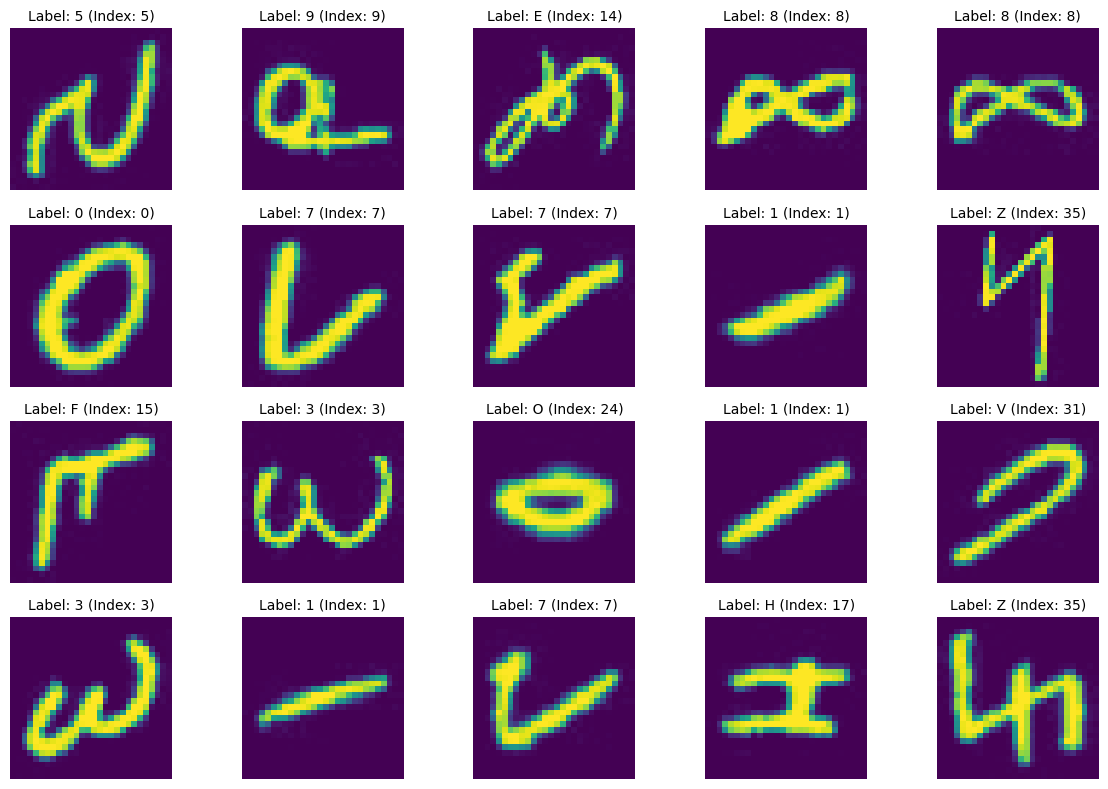

In [7]:
visualize_dataset_samples(dataset, num_samples=20)

# Data Preprocessing

In [8]:
# Preprocess function: reshape, normalize, one-hot encode
def preprocess_data(image, label):
    image = tf.image.resize(image, IMG_SIZE) / 255.0  # Normalize pixel values
    label = tf.one_hot(label, NUM_CLASSES)  # One-hot encode labels
    return image, label

# Augmentation function
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label

# Preprocess data
dataset = dataset.map(preprocess_data)

# Split data into train and validation sets
dataset = dataset.shuffle(1000)  # Shuffle before splitting

# Apply augmentation to train dataset
train_dataset = dataset.take(TRAIN_SIZE).map(augment_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = dataset.skip(TRAIN_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

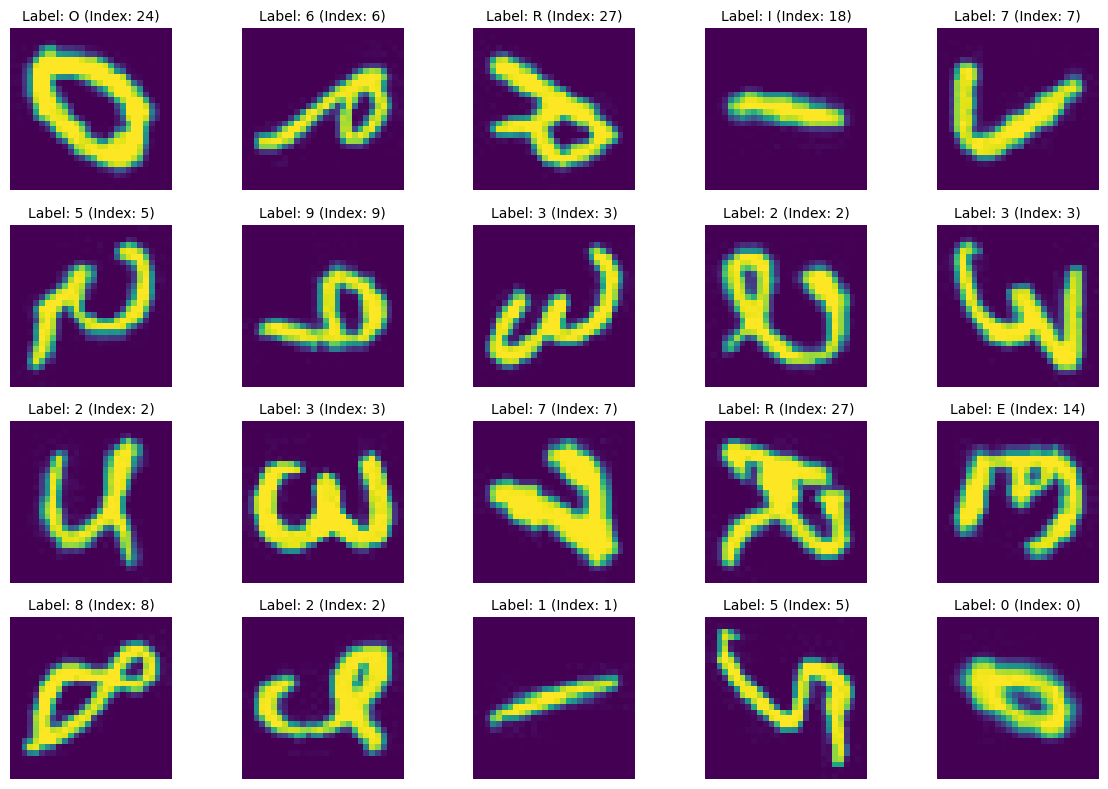

In [32]:
visualize_dataset_samples(train_dataset.unbatch(), num_samples=20)

# Create Resnet18 Model

In [10]:
def identity_block(x, filters, block_name):
    """Identity block for ResNet18."""
    x_shortcut = x

    # First convolution
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv1")(x)
    x = BatchNormalization(name=f"{block_name}_bn1")(x)
    x = Activation("relu", name=f"{block_name}_relu1")(x)

    # Second convolution
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv2")(x)
    x = BatchNormalization(name=f"{block_name}_bn2")(x)

    # Skip connection
    x = Add(name=f"{block_name}_add")([x, x_shortcut])
    x = Activation("relu", name=f"{block_name}_relu2")(x)

    return x

def convolutional_block(x, filters, strides=(2, 2), block_name="conv_block"):
    """Residual block with downsampling."""
    x_shortcut = Conv2D(filters, (1, 1), strides=strides, padding="same", name=f"{block_name}_shortcut")(x)
    x_shortcut = BatchNormalization(name=f"{block_name}_bn_shortcut")(x_shortcut)

    # First convolution (applies stride)
    x = Conv2D(filters, (3, 3), strides=strides, padding="same", name=f"{block_name}_conv1")(x)
    x = BatchNormalization(name=f"{block_name}_bn1")(x)
    x = Activation("relu", name=f"{block_name}_relu1")(x)

    # Second convolution (no stride)
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv2")(x)
    x = BatchNormalization(name=f"{block_name}_bn2")(x)

    # Skip connection
    x = Add(name=f"{block_name}_add")([x, x_shortcut])
    x = Activation("relu", name=f"{block_name}_relu2")(x)

    return x

def ResNet18(input_shape=(28, 28, 1), num_classes=NUM_CLASSES):
    inputs = Input(shape=input_shape, name="input_layer")

    # Initial Conv Layer
    x = Conv2D(64, (5, 5), strides=2, padding="same", activation="relu", name="initial_conv")(inputs)
    x = BatchNormalization(name="initial_bn")(x)
    x = MaxPooling2D((3, 3), strides=2, padding="same", name="initial_pool")(x)

    # ResNet Blocks
    x = identity_block(x, 64, block_name="block1_1")
    x = identity_block(x, 64, block_name="block1_2")

    x = convolutional_block(x, 128, block_name="block2_1")  # Downsampling here
    x = identity_block(x, 128, block_name="block2_2")

    x = convolutional_block(x, 256, block_name="block3_1")  # Downsampling here
    x = identity_block(x, 256, block_name="block3_2")

    x = convolutional_block(x, 512, block_name="block4_1")  # Downsampling here
    x = identity_block(x, 512, block_name="block4_2")

    # Classification Head
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    outputs = Dense(num_classes, activation="softmax", name="output_layer")(x)

    model = Model(inputs, outputs, name="ResNet18")
    return model

# Build model
model = ResNet18()

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Summarize model
model.summary()

Model: "ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 14, 14,    │      1,664 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_bn          │ (None, 14, 14,    │        256 │ initial_conv[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_pool        │ (None, 7, 7, 64)  │          0 │ initial_bn[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv1      │ (None, 7, 7, 64)  │     36,928 │ initial_pool[0][… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn1        │ (None, 7, 7, 64)  │        256 │ block1_1_conv1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu1      │ (None, 7, 7, 64)  │          0 │ block1_1_bn1[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv2      │ (None, 7, 7, 64)  │     36,928 │ block1_1_relu1[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn2        │ (None, 7, 7, 64)  │        256 │ block1_1_conv2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_add (Add)  │ (None, 7, 7, 64)  │          0 │ block1_1_bn2[0][… │
│                     │                   │            │ initial_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu2      │ (None, 7, 7, 64)  │          0 │ block1_1_add[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv1      │ (None, 7, 7, 64)  │     36,928 │ block1_1_relu2[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn1        │ (None, 7, 7, 64)  │        256 │ block1_2_conv1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_relu1      │ (None, 7, 7, 64)  │          0 │ block1_2_bn1[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv2      │ (None, 7, 7, 64)  │     36,928 │ block1_2_relu1[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn2        │ (None, 7, 7, 64)  │        256 │ block1_2_conv2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_add (Add)  │ (None, 7, 7, 64)  │          0 │ block1_2_bn2[0][

 Total params: 11,201,572 (42.73 MB)

 Trainable params: 11,191,972 (42.69 MB)

 Non-trainable params: 9,600 (37.50 KB)

# Train Model

In [11]:
# Checkpoint to save the best model
model_checkpoint = ModelCheckpoint('resnet18.keras', monitor='val_accuracy', mode='max', save_best_only=False, verbose=1)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',  # Watch validation loss
    factor=0.5,          # Reduce LR by half
    patience=3,          # Wait 3 epochs before reducing
    verbose=1,           # Print updates
    min_lr=1e-6          # Set a lower bound for LR
)

# Train the model
model_history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, callbacks=[model_checkpoint, lr_scheduler, early_stopping])

# Save model
model.save("resnet18_final.keras")

Epoch 1/20


I0000 00:00:1740022421.064768     761 service.cc:148] XLA service 0x7ed5b800f720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1740022421.065710     761 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-02-19 22:33:41.629842: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1740022423.563467     761 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-02-19 22:33:44.857704: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[64,64,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,7,7]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_m

      5/Unknown 26s 29ms/step - accuracy: 0.0339 - loss: 4.8559  

I0000 00:00:1740022433.912500     761 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   6673/Unknown 149s 18ms/step - accuracy: 0.8034 - loss: 0.6337

...


Epoch 17: saving model to resnet18.keras
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 160s 24ms/step - accuracy: 0.9477 - loss: 0.1260 - val_accuracy: 0.9331 - val_loss: 0.1829 - learning_rate: 5.0000e-05
Epoch 18/20
6674/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9495 - loss: 0.1216

2025-02-19 23:21:47.311853: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 6896793212615329725
2025-02-19 23:21:47.311907: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 17780334201947870426



Epoch 18: saving model to resnet18.keras

Epoch 18: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 162s 24ms/step - accuracy: 0.9495 - loss: 0.1216 - val_accuracy: 0.9329 - val_loss: 0.1847 - learning_rate: 5.0000e-05
Epoch 19/20
6674/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9515 - loss: 0.1156

2025-02-19 23:24:27.454963: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 6896793212615329725
2025-02-19 23:24:27.455055: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 17780334201947870426



Epoch 19: saving model to resnet18.keras
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 161s 24ms/step - accuracy: 0.9515 - loss: 0.1156 - val_accuracy: 0.9332 - val_loss: 0.1854 - learning_rate: 2.5000e-05
Epoch 20/20
6674/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9533 - loss: 0.1109
Epoch 20: saving model to resnet18.keras
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 162s 24ms/step - accuracy: 0.9533 - loss: 0.1109 - val_accuracy: 0.9331 - val_loss: 0.1867 - learning_rate: 2.5000e-05


# Evaluate Model

In [49]:
import matplotlib.pyplot as plt

def plot_accuracy_loss(model_history):
    """
    Plots model training history for accuracy and loss, annotating the first and last points.
    """
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Extract relevant metrics
    accuracy = model_history.history.get("accuracy", [])
    val_accuracy = model_history.history.get("val_accuracy", [])
    loss = model_history.history.get("loss", [])
    val_loss = model_history.history.get("val_loss", [])

    epochs = range(1, len(accuracy) + 1)

    # Accuracy subplot
    ax[0].plot(epochs, accuracy, label="Training Accuracy", marker="o")
    ax[0].plot(epochs, val_accuracy, label="Validation Accuracy", marker="s")
    ax[0].set_title("Model Accuracy")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()
    ax[0].grid(True, linestyle="--", alpha=0.6)

    # Annotate first and last points
    if accuracy:
        ax[0].text(1, accuracy[0], f"{accuracy[0]:.4f}", fontsize=10, ha='left', va='top')
        ax[0].text(epochs[-1], accuracy[-1], f"{accuracy[-1]:.4f}", fontsize=10, ha='left', va='bottom')
    if val_accuracy:
        ax[0].text(1, val_accuracy[0], f"{val_accuracy[0]:.4f}", fontsize=10, ha='left', va='top', color="blue")
        ax[0].text(epochs[-1], val_accuracy[-1], f"{val_accuracy[-1]:.4f}", fontsize=10, ha='left', va='top', color="blue")

    # Loss subplot
    ax[1].plot(epochs, loss, label="Training Loss", marker="o")
    ax[1].plot(epochs, val_loss, label="Validation Loss", marker="s")
    ax[1].set_title("Model Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].legend()
    ax[1].grid(True, linestyle="--", alpha=0.6)

    # Annotate first and last points
    if loss:
        ax[1].text(1, loss[0], f"{loss[0]:.4f}", fontsize=10, ha='left', va='bottom')
        ax[1].text(epochs[-1], loss[-1], f"{loss[-1]:.4f}", fontsize=10, ha='left', va='top')
    if val_loss:
        ax[1].text(1, val_loss[0], f"{val_loss[0]:.4f}", fontsize=10, ha='left', va='bottom', color="blue")
        ax[1].text(epochs[-1], val_loss[-1], f"{val_loss[-1]:.4f}", fontsize=10, ha='left', va='top', color="blue")

    plt.tight_layout()
    plt.show()

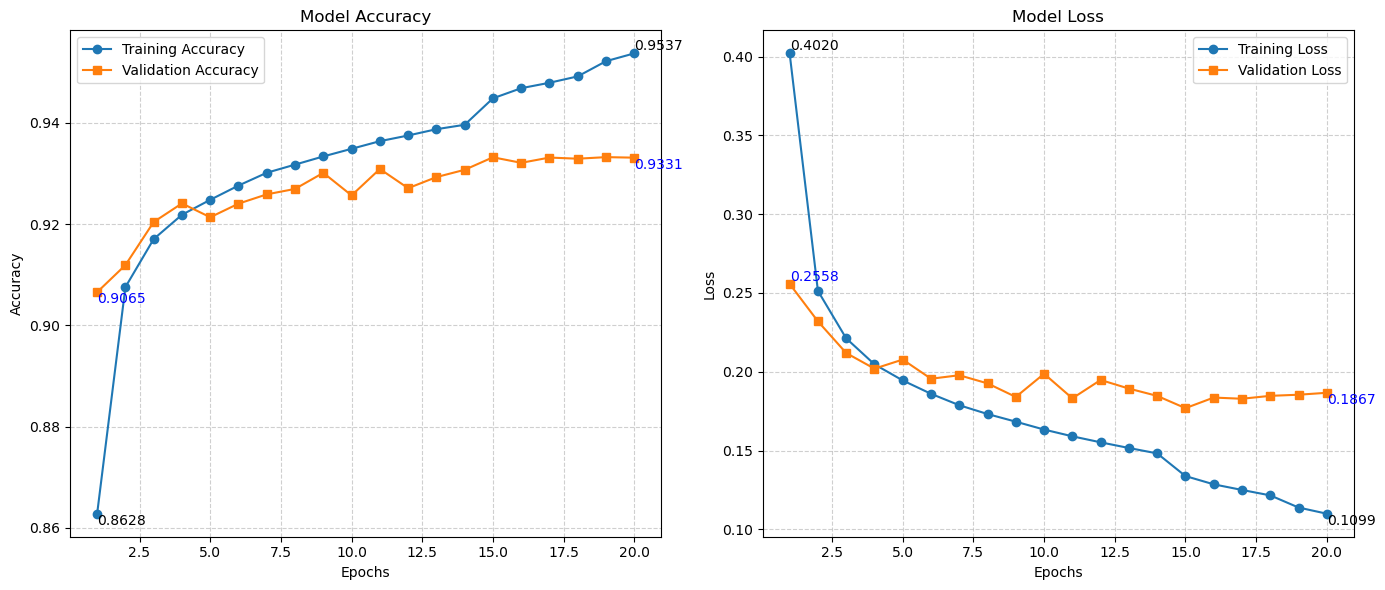

In [50]:
plot_accuracy_loss(model_history)

In [22]:
def extract_predictions(model, dataset, num_samples=20):
    """
    Extracts true labels and predicted labels from the dataset.
    
    Args:
        model (tf.keras.Model): Trained model.
        dataset (tf.data.Dataset): Dataset containing images and labels.
        num_samples (int): Number of sample images to store for visualization.
    
    Returns:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.
        sample_images (list): A few sample images.
        sample_labels (list): True labels of the sample images.
        sample_preds (list): Predicted labels of the sample images.
    """
    y_true = []
    y_pred = []
    sample_images = []
    sample_labels = []
    sample_preds = []

    for images, labels in dataset:
        # Convert one-hot encoded labels to class indices
        y_true.append(np.argmax(labels, axis=1))
        preds = model.predict(images, verbose=0)
        y_pred.append(np.argmax(preds, axis=1))

        # Store a few sample images with predictions
        if len(sample_images) < num_samples:
            for i in range(min(len(images), num_samples - len(sample_images))):
                sample_images.append(images[i].numpy())
                sample_labels.append(np.argmax(labels[i].numpy()))
                sample_preds.append(np.argmax(preds[i]))

    # Concatenate all batches into single arrays
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    return y_true, y_pred, sample_images, sample_labels, sample_preds


def compute_metrics(y_true, y_pred, class_names):
    """
    Computes precision, recall, F1-score, and displays the confusion matrix.
    
    Args:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.
        class_names (dict): Dictionary mapping label indices to characters.
    """
    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average="macro", zero_division=1)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=1)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=1)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=[class_names[i] for i in sorted(class_names.keys())],
                yticklabels=[class_names[i] for i in sorted(class_names.keys())])
    plt.title('Confusion Matrix', fontsize=18)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def display_sample_predictions(sample_images, sample_labels, sample_preds, class_names, num_samples=20):
    """
    Displays a few sample predictions with corresponding images.
    
    Args:
        sample_images (list): List of sample images.
        sample_labels (list): List of true labels.
        sample_preds (list): List of predicted labels.
        class_names (dict): Dictionary mapping label indices to characters.
        num_samples (int): Number of images to display.
    """
    plt.figure(figsize=(12, 8))
    for i in range(num_samples):
        plt.subplot(4, 5, i + 1)
        plt.imshow(sample_images[i])
        plt.title(f"Pred: {class_names[sample_preds[i]]} (Index: {sample_preds[i]})\n"
                  f"True: {class_names[sample_labels[i]]} (Index: {sample_labels[i]})", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [15]:
y_true, y_pred, sample_images, sample_labels, sample_preds = extract_predictions(model, val_dataset, 27)

2025-02-19 23:29:05.582943: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,64,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,7,7]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-02-19 23:29:05.702975: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,128,4,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,4,4]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFo

Precision: 0.9399
Recall: 0.9316
F1-score: 0.9348


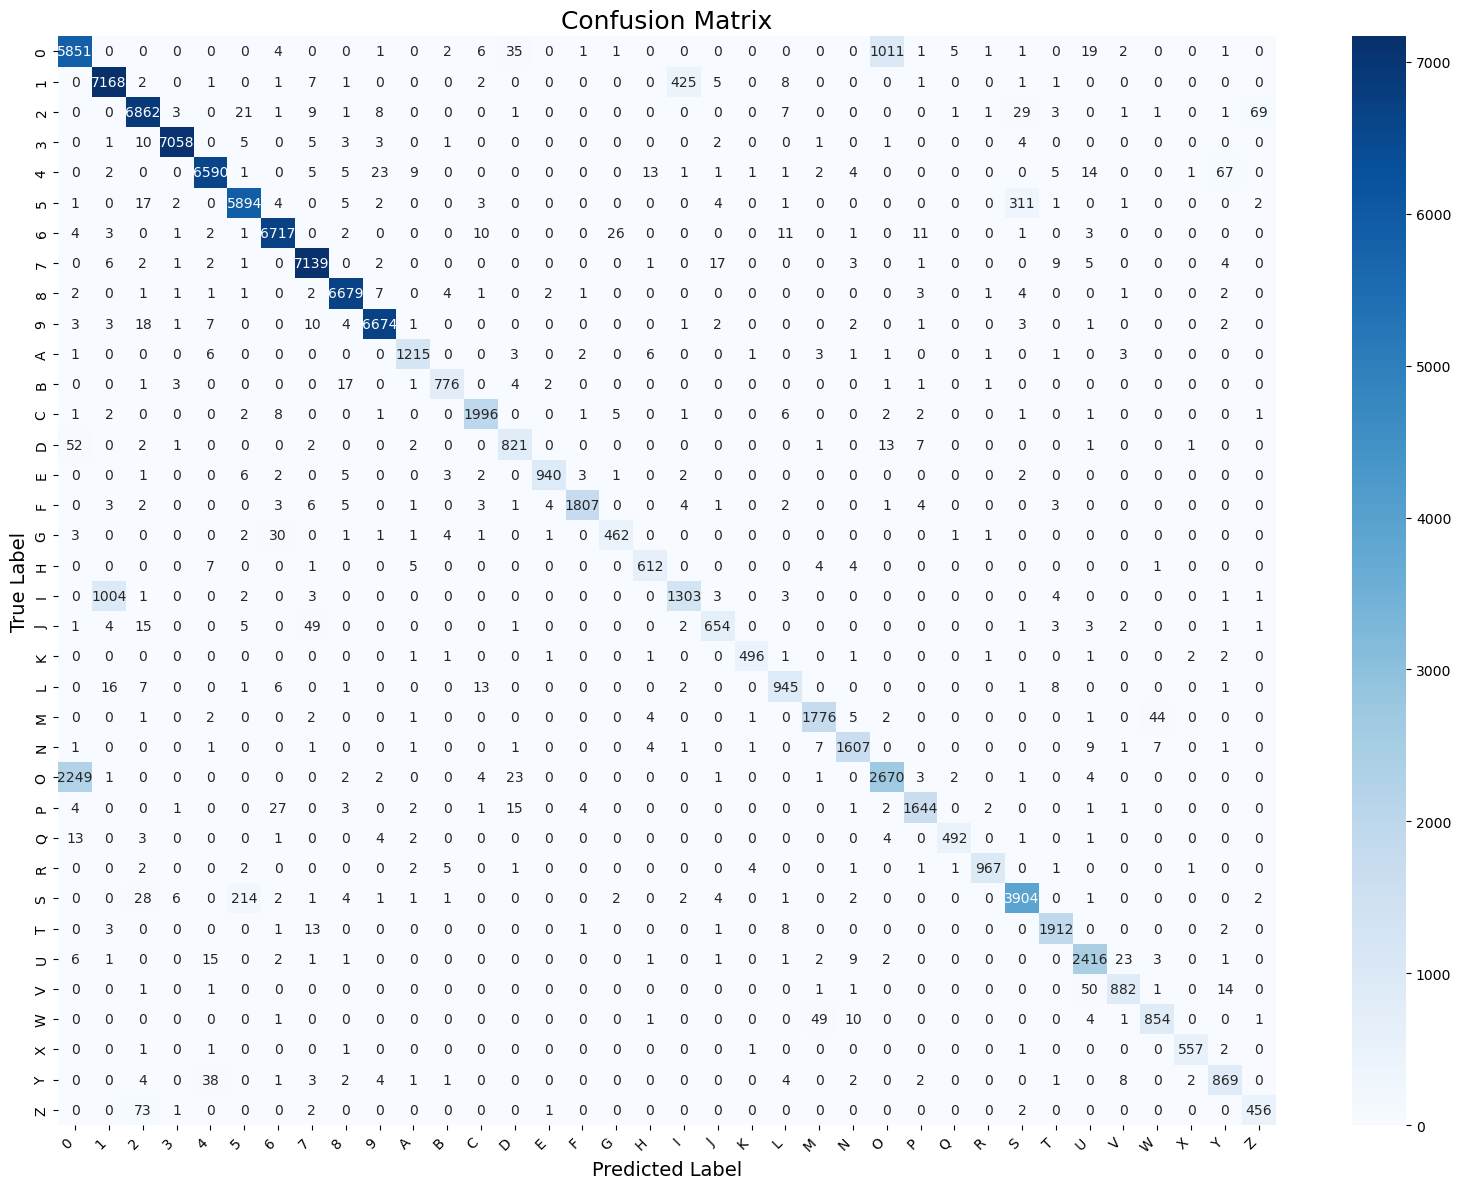

In [16]:
compute_metrics(y_true, y_pred, label_dict)

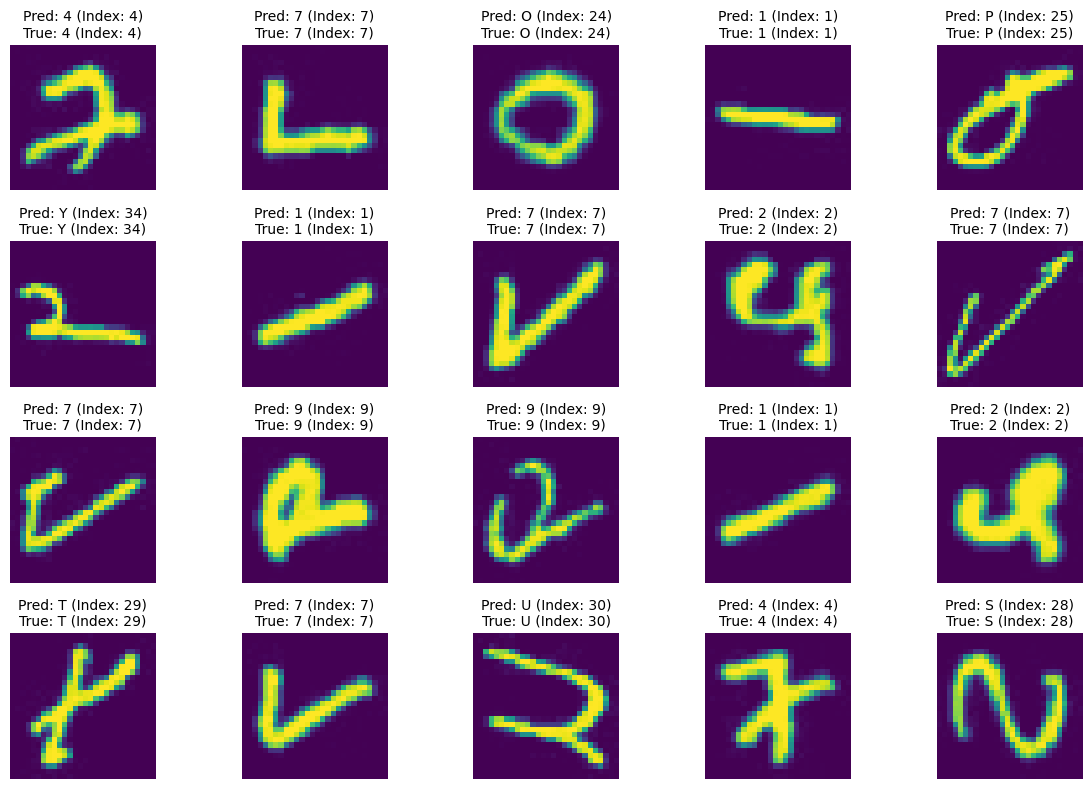

In [24]:
display_sample_predictions(sample_images, sample_labels, sample_preds, label_dict, 20)